# ** 3. Identification of the two flow regimes ** 

For the range of (Ra, Pr) considered, two different dynamical regimes have been identified by following the global angular momentum
\begin{equation}
A_{2D} (t) \equiv -\frac{1}{2}\int \vec{x}^2 \omega (\vec{x},t) d\vec{x},
\mbox{ with } \omega (\vec{x},t) = \partial_x v - \partial_y u
\end{equation}
as a function of time, since this quantity provides a measure of the organised rotation around the centre of the cavity. 
A criterion based on the amplitude of $A_{2D}$ was proposed to discriminate the two regimes (Podvin & Sergent 2015; Castillo-Castellanos et al. 2016). If $\vert A_{2D} \vert > A_{thres}$ (here set to $A_{thres} = \overline{\vert A_{2D}} \vert + \sigma\left(\vert A_{2D} \vert\right)$) during the interval between two consecutive sign changes in $A_{2D}$, then the time interval is assigned to the regime of **consecutive reversals (CR)**.
A time interval where such threshold is not reached can be of two kinds: weak or rogue reversals, and a cessation of the LSC. For simplicity, both kinds are assigned to the regime of **extended cessations (EC)**.

** This routine concerns figure 1 from section 3 of the article "Conditional statistics of the large-scale reversal dynamics in square Rayleigh–Bénard cells" **

## Preamble

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',10)

params = {'backend': 'ps',
          'axes.labelsize': 16,
          'font.size': 16,
          'legend.fontsize': 16,          
          'font.size': 16,          
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'text.usetex': True,
          'font.family': 'serif',
          'figure.figsize': (12, 8),
          'contour.negative_linestyle':'dashed'}
plt.rcParams.update(params)

## 1. Read the time series

In [2]:
filename_modes_pr3   = './data_from_dns/modal_50000000_3_512_016to186.h5'
filename_global_pr3  = './data_from_dns/global_50000000_3_512_016to186.h5'
filename_nusselt_pr3 = './data_from_dns/nusselt_50000000_3_512_016to186.h5'

filename_modes_pr43   = './data_from_dns/modal_50000000_4.3_512_060to259.h5'
filename_global_pr43  = './data_from_dns/global_50000000_4.3_512_060to259.h5'
filename_nusselt_pr43 = './data_from_dns/nusselt_50000000_4.3_512_060to259.h5'

In [3]:
glb_pr3 = pd.read_hdf(filename_global_pr3)
glb_pr3['l2d']  = glb_pr3['l2d']/glb_pr3['l2d'].abs().mean()
glb_pr3['f'] = glb_pr3['l2d'].abs()

scale=glb_pr3['ekin'].mean()
glb_pr3['ekin']  = glb_pr3['ekin']/scale
glb_pr3['epot']  = glb_pr3['epot']/scale
glb_pr3['bpot']  = glb_pr3['bpot']/scale

scale = glb_pr3['m2d'].abs().mean()
glb_pr3['m2d']  = glb_pr3['m2d']/scale
glb_pr3['ia2d']  = glb_pr3['ia2d']/scale
glb_pr3['ib2d']  = glb_pr3['ib2d']/scale

thres_pr3=glb_pr3.mean()['f'] + glb_pr3.std()['f']
nus_pr3 = pd.read_hdf(filename_nusselt_pr3)

n=glb_pr3.shape[0]
t = np.arange(n)/20.
glb_pr3['t'] = t
glb_pr3['apot'] = glb_pr3['epot']-glb_pr3['bpot']
nus_pr3['t'] = t

In [4]:
glb_pr43 = pd.read_hdf(filename_global_pr43)
glb_pr43['l2d'] =  glb_pr43['l2d']/glb_pr43['l2d'].abs().mean()
glb_pr43['f'] = glb_pr43['l2d'].abs()

scale=glb_pr43['ekin'].mean()
glb_pr43['ekin']  = glb_pr43['ekin']/scale
glb_pr43['epot']  = glb_pr43['epot']/scale
glb_pr43['bpot']  = glb_pr43['bpot']/scale

scale = glb_pr43['m2d'].abs().mean()
glb_pr43['m2d']  = glb_pr43['m2d']/scale
glb_pr43['ia2d']  = glb_pr43['ia2d']/scale
glb_pr43['ib2d']  = glb_pr43['ib2d']/scale


thres_pr43=glb_pr43.mean()['f'] + glb_pr43.std()['f']

nus_pr43 = pd.read_hdf(filename_nusselt_pr43)

n=glb_pr43.shape[0]
t = np.arange(n)/20.
glb_pr43['t'] = t
nus_pr43['t'] = t
glb_pr43['apot'] = glb_pr43['epot']-glb_pr43['bpot']

## 2. Identify the instances where $A_{2D}$ changes sign

In [5]:
def crossings(x,y,z,c):
    x0 = pd.DataFrame() 
   
    n = y.shape[0]
    index = np.where((y[0:n-2]-c)*(y[1:n-1]-c) < 0)
    index = np.asarray(index)
    index = index.T[:,0]
    m = index.shape[0]
    
    x0['ti'] = x[index.T[0:m-1]]
    x0['tm'] = 0.5*(x[index.T[0:m-1]] + x[index.T[1:m]])
    x0['tf'] = x[index.T[1:m]]
    x0['tau'] = x0['tf'] - x0['ti']
    midpoint = (index.T[1:m]-index.T[0:m-1])/2 + index.T[0:m-1]    
    x0['tm'] = x[midpoint.astype(int)]    
    
    x0['idxi'] = index.T[0:m-1]
    x0['idxf'] = index.T[1:m]
    
    c = np.zeros((m-1,))    
    for n in range(0, m-1):
        a = np.max(z[np.arange(index.T[n],index.T[n+1])])
        b = np.min(z[np.arange(index.T[n],index.T[n+1])])
        c[n] = a if a>-b else b        
        
    x0['ymax'] = c
    
    
    return x0, index.T;

zero_pr3, _ = np.array(crossings(glb_pr3.t.values, glb_pr3.l2d.values, glb_pr3.l2d.values,0.))
zero_pr3['isrev'] = zero_pr3['ymax'].abs() > thres_pr3

zero_pr43, _ = np.array(crossings(glb_pr43.t.values, glb_pr43.l2d.values, glb_pr43.l2d.values,0.))
zero_pr43['isrev'] = zero_pr43['ymax'].abs() > thres_pr43

## 3. Assign each time interval to the CR or EC regimes.

In [6]:
def amplitude_filter(zero,glb):
    nrev=zero.ti.loc[zero.isrev==True].shape

    n=glb.shape[0]
    d= np.zeros((n,),dtype=bool)
    for nr in range(0, nrev[0]-1):
        tin = zero.ti.loc[zero.isrev==True].values[nr]
        tfn = zero.tf.loc[zero.isrev==True].values[nr]
        c = np.where(np.equal((glb.t > tin),(glb.t <= tfn)))
        d[c] = True

    glb['CRregime'] = d
    return glb; 

amplitude_filter(zero_pr43,glb_pr43)
amplitude_filter(zero_pr3,glb_pr3)

,t,l2d,ekin,phiy,epot,bpot,phid,etmp,m2d,ia2d,ib2d,f,apot,CRregime
0,0.00,1.040195,1.292703,36.393014,0.712508,-1.771402,25.708754,0.128320,0.756329,-0.007763,8.336508,1.040195,2.483910,False
1,0.05,1.031262,1.297463,36.102107,0.704982,-1.770105,26.099650,0.128354,0.742312,-0.041236,1.312467,1.031262,2.475087,False
2,0.10,1.021298,1.301721,35.700902,0.697591,-1.767601,26.723235,0.128371,0.730250,-0.045148,1.333577,1.021298,2.465192,False
3,0.15,1.010519,1.305408,35.187878,0.690421,-1.766177,27.574482,0.128384,0.720735,-0.048627,1.367210,1.010519,2.456598,False
4,0.20,0.999150,1.308470,34.582274,0.683513,-1.763256,28.563897,0.128395,0.712286,-0.052197,1.392251,0.999150,2.446770,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
854995,42749.75,0.021947,0.675932,11.722339,1.542296,-2.075972,16.477598,0.131437,0.709895,-0.049099,0.519999,0.021947,3.618268,False
854996,42749.80,0.024230,0.674462,12.130161,1.543923,-2.075599,16.347401,0.131445,0.712810,-0.051340,0.543346,0.024230,3.619521,False
854997,42749.85,0.026183,0.673158,12.601589,1.545429,-2.074523,16.163142,0.131454,0.709394,-0.053602,0.559866,0.026183,3.619951,False
854998,42749.90,0.027804,0.672047,13.138673,1.546783,-2.072842,15.939892,0.131464,0.699564,-0.055850,0.569538,0.027804,3.619625,False


## 4. Write the results for the other routines to use

In [7]:
filename_global_pr3  = './data_from_dns/global_50000000_3_512_016to186.h5'
filename_global_pr43  = './data_from_dns/global_50000000_4.3_512_060to259.h5'

glb_pr3.to_hdf(filename_global_pr3, '/glb_pr3', table=True, mode='w', compression='blosc:lz4', complevel=9, fletcher32=True)
glb_pr43.to_hdf(filename_global_pr43, '/glb_pr3', table=True, mode='w', compression='blosc:lz4', complevel=9, fletcher32=True)

## 5. Separation of flow regimes for $(Ra=5\cdot10^7,Pr=3.0)$ (figure 1a)

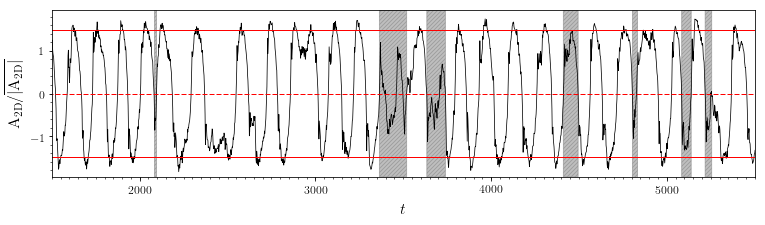

In [8]:
plt.rcParams['figure.figsize'] = (10.5, 3.0)

import matplotlib.transforms as mtransforms
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

f, ax = plt.subplots(1, 1, sharey=False, sharex=True)
skip=40
glb_pr3.iloc[::skip, :].plot(x='t', y='l2d', lw=0.75, c='k', alpha=1.0, legend=False, xlim=[1500,5500], ylim=[-1.95,1.95], ax=ax, rasterized=True);

ax.plot((0,8000),(0,0),'red',linewidth=1.0, linestyle='--', dashes=(5, 2), rasterized=True)
ax.plot(( thres_pr3,8000),( thres_pr3, thres_pr3),'red',linewidth=1.0, rasterized=True)
ax.plot((-thres_pr3,8000),(-thres_pr3,-thres_pr3),'red',linewidth=1.0, rasterized=True)


trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
ax.fill_between(glb_pr3.t, 0, 1, where=glb_pr3.CRregime == False, color='gray',facecolor='gray', hatch = '//////', alpha=0.5, transform=trans, rasterized=True)

majorLocator_x = MultipleLocator(1000)
minorLocator_x = MultipleLocator(50)
ax.xaxis.set_major_locator(majorLocator_x)
ax.xaxis.set_minor_locator(minorLocator_x)
ax.set_xlabel('$t$')

majorLocator_y = MultipleLocator(1.0)
minorLocator_y = MultipleLocator(0.2)
ax.yaxis.set_major_locator(majorLocator_y)
ax.yaxis.set_minor_locator(minorLocator_y)
ax.set_ylabel('$\mathrm{A_{2D}} /\overline{\\vert\mathrm{A_{2D}}\\vert}$')

plt.tight_layout(pad=0.25) 
plt.savefig('figures_for_article/figure1a.pdf',dpi=200)